# Análisis de Paro en la Encuesta de Población Activa del INE

## 1. Introducción

En este proyecto nos centraremos en analizar el paro en España a partir de los datos proporcionados por la Encuesta de Población Activa (EPA) elaborada por el instituto Nacional de Estadística (INE).
La encuesta consta de una investigación continua y de periodicidad trimestral dirigida a viviendas familiares cuya finalidad es obtener datos de la actividad laboral y de sus categorías (ocupados, parados), así como la población ajena a esta (inactivos).

La Ley asigna al Instituto Nacional de Estadística un papel destacado en la actividad estadística pública encomendándole expresamente la realización de las operaciones estadísticas de gran envergadura (censos demográficos y económicos, cuentas nacionales, estadísticas demográficas y sociales, indicadores económicos y sociales, coordinación y mantenimiento de los directorios de empresas, formación del Censo Electoral...).

Historicamente el paro en España ha sido siempre uno de los grandes obstáculos de la economía del país, siempre presente en los rankings europeos desde hace años. Debido a estas preocupantes cifras, he creido preciso hacer un estudio para indagar sobre como fluctua la situación laboral de los españoles entre los años 2019 a 2024, pasándo por la crisis del COVID-19 y observando sus consecuencias.

In [1]:
#Cargamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

## 2. Objetivos

Nos centraremos principalmente en los índices de paro. Separaremos por las franjas de edades, sexo y formación académica. Después separaremos el paro en Comunidades Autónomas. Nos centraremos en las siguientes cuestiones:

- Hombres/Mujeres: Sigue siendo el sexo masculino el predominante en el sector laboral? Como afecta el paro a las mujeres comparado con los hombres?

- Edad: Son de verdad los jovenes los más afectados por el paro? Cual es la diferencia con el resto de franjas de edades? Los mayores entre 55 y 64 años son un grupo vulnerable?

- General: Como ha oscilado el paro general entre 2019 y 2024?

- Estudios: Cual es la correlación entre paro y los diferentes niveles de formación? Hay una gran diferencia entre los estudios medios (FP) con estudios superiores?

- Duración del paro: Como ha ido cambiando la duración de paro durante los años?

- Comunidades Autónomas: Que comunidades autónomas son las que más paro tienen? Y las que menos?

- COVID-19: Cuales han sido los grupos más y menos afectados por el COVID-19? Que comunidades Autónomas han gestionado mejor y peor la crisis?

## 3. Filtro y limpieza de los datos

Usando pandas obtendremos las tablas que contienen toda la información de los parámetros de la encuesta.
Condensaremos la información para reducirnos únicamente a lo que nos interesa para nuestro estudio y acabaremos la sección limpiando los datos para que sea compatible con diferentes transformaciones


La encuesta se separa por trimestres, he descargado los archivos .csv de cada primer trimestre de cada año y obtendremos una visión parcial (aunque suficiente) de los datos de la vida laboral del país.

In [45]:
#Cargamos los .csv y los convertimos en dataframes
# Cargamos todos los trimestres de cada año y concatenamos sus trimestres en un único dataframe por año
dfs19 = []
dfs20 = []
dfs21 = []
dfs22 = []
dfs23 = []
dfs24 = []

for t in range(1, 5):
    archivo19 = f"data/EPA_2019T{t}.csv"
    dfs19.append(pd.read_csv(archivo19, sep="\t"))
    archivo20 = f"data/EPA_2020T{t}.csv"
    dfs20.append(pd.read_csv(archivo20, sep="\t"))
    archivo21 = f"data/EPA_2021T{t}.csv"
    dfs21.append(pd.read_csv(archivo21, sep="\t"))
    archivo22 = f"data/EPA_2022T{t}.csv"
    dfs22.append(pd.read_csv(archivo22, sep="\t"))

    # Para 2023 puede ser .csv o .tab
    archivo23_csv = f"data/EPA_2023T{t}.csv"
    archivo23_tab = f"data/EPA_2023T{t}.tab"
    try:
        dfs23.append(pd.read_csv(archivo23_csv, sep="\t"))
    except FileNotFoundError:
        try:
            dfs23.append(pd.read_csv(archivo23_tab, sep="\t"))
        except FileNotFoundError:
            print(f"Archivo de 2023 T{t} no encontrado en .csv ni .tab")

    archivo24 = f"data/EPA_2024T{t}.tab"
    try:
        dfs24.append(pd.read_csv(archivo24, sep="\t"))
    except FileNotFoundError:
        # Por si hay algún trimestre solo disponible en .csv
        archivo24csv = f"data/EPA_2024T{t}.csv"
        try:
            dfs24.append(pd.read_csv(archivo24csv, sep="\t"))
        except FileNotFoundError:
            print(f"Archivo de 2024 T{t} no encontrado en .tab ni .csv")

df19 = pd.concat(dfs19, ignore_index=True)
df20 = pd.concat(dfs20, ignore_index=True)
df21 = pd.concat(dfs21, ignore_index=True)
df22 = pd.concat(dfs22, ignore_index=True)
df23 = pd.concat(dfs23, ignore_index=True)
df24 = pd.concat(dfs24, ignore_index=True)

Antes de hacer nada, vemos que a partir de 2021 la tabla "EDAD5" cambia a "EDAD1" como queremos juntar todas estos dataframes en uno solo es necesario que todas las columnas sean iguales ya que si no lo hacemos perderemos información importante.

In [3]:
print("¿EDAD5 en df20?", "EDAD5" in df20.columns)
print("¿EDAD5 en df21?", "EDAD5" in df21.columns)
print("¿EDAD1 en df21?", "EDAD1" in df21.columns)

¿EDAD5 en df20? True
¿EDAD5 en df21? False
¿EDAD1 en df21? True


Corregimos:

In [4]:
for df in [df21,df22, df23, df24]:
    df.rename(columns={"EDAD1": "EDAD5"}, inplace=True)

Ahora sí podemos concatenar los dataframes para obtener un dataframe con todos los años.

In [5]:
df = pd.concat([df19, df20, df21, df22,df23,df24], ignore_index=True)

df.head()

,CICLO,CCAA,PROV,NVIVI,NIVEL,NPERS,EDAD5,RELPP1,SEXO1,NCONY,...,CSE,FACTOREL,OBJFORM,RELLB3,RZULT,DAUSVAC,DAUSENF,DAUSOTR,RELLB4,HOREPLU
0,186,16,1,1,1,1,35,1,1,2,...,16,254.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,186,16,1,1,1,2,35,2,6,1,...,14,254.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,186,16,1,1,2,3,0,3,6,0,...,,186.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,186,16,1,2,1,1,45,1,6,0,...,13,224.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,186,16,1,2,1,2,20,3,1,0,...,,224.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como acabamos de ver la tabla tiene 101 columnas. Esos son muchísimos parámetros, más de los necesarios para este estudio.
Limitaremos el dataframe a las siguientes columnas:

In [6]:
variables_empleo_paro = [
    "CICLO",
    "EDAD5",   # grupo de edad en tramos de 5 años
    "SEXO1",   # sexo de la persona
    "CCAA",    # comunidad autónoma de residencia
    "PROV",    # provincia de residencia
    "NFORMA",  # nivel máximo de estudios alcanzado
    "CURSR",   # si está cursando estudios reglados actualmente
    "ECIV1",   # estado civil legal
    "NAC1",    # nacionalidad
    "TRAREM",  # trabajó la semana pasada con remuneración
    "AYUDFA",  # ayuda familiar no remunerada en negocio familiar
    "AUSENT",  # tiene empleo pero estuvo ausente la semana pasada
    "RZNOTB",  # razón por la que no trabajó teniendo empleo
    "VINCUL",  # tipo de vínculo con el empleo del ausente
    "BUSCA",   # ha buscado empleo en las últimas 4 semanas
    "DESEA",   # desea tener un empleo
    "FOBACT",  # tipo de búsqueda de empleo (activa o no)
    "NBUSCA",  # razón por la que no busca empleo
    "EMPANT",  # ha trabajado antes en algún empleo
    "DTANT",   # meses desde que dejó su último empleo
    "OCUP1",   # ocupación en el empleo principal
    "ACT1",    # actividad económica del empleo principal
    "SITU",    # situación profesional (asalariado, autónomo, etc.)
    "ITBU",    # tiempo que lleva buscando empleo
    "OFEMP",   # relación con la oficina pública de empleo
    "AOI",     # clasificación OIT: ocupado, parado, inactivo (derivada)
    "FACTOREL" # factor de elevación para ponderar cada registro
]

df = df[variables_empleo_paro]

La columna de "CICLO" indica en que trimestre se hizo el estudio. Como hemos cogido el primer trimestre de cada año cambiaremos el nombre y los items de la columna.

In [7]:
# Asignar año usando bins (como antes), no como texto con trimestre.
df = df.rename(columns={"CICLO": "AÑO"})

# Se asume que los valores en la columna AÑO son tipo 186, 187, 188, 189, etc.
# Creamos los bins para convertir cada bloque de 4 códigos en el año correspondiente

bins = [185.5, 189.5, 193.5, 197.5, 201.5, 205.5, 209.5]  # Cada 4 suma 1 año (2019-2024)
labels = [2019, 2020, 2021, 2022, 2023, 2024]
df['AÑO'] = pd.cut(df['AÑO'], bins=bins, labels=labels)


Empezaremos con el refinamiento de datos. Veamos que para algunos items tenemos formatos diferentes, como por ejemplo tenemos '06' y 6.0 o tambien ' ' y NaN. Esto es un problema ya que en la base de datos se registran como elementos diferentes cuando representan lo mismo dentro de la encuesta.

In [8]:
print(df["NBUSCA"].unique())
print(df["AOI"].unique())
print(df["CCAA"].unique())
print(df["EDAD5"].unique())

['  ' '06' '03' '08' '05' '01' '07' '04' '00' '02' nan 6.0 3.0 4.0 7.0 5.0
 8.0 1.0 2.0 0.0]
['04' '03' '  ' '05' '09' '06' '08' '07' 4.0 9.0 nan 6.0 3.0 5.0 7.0 8.0]
[16  8 10  1  7 11  4  9 12  2 17 13 14 15  3  5  6 51 52]
[35  0 45 20 16 40 10  5 50 30 65 25 55 60]


Vemos que el tipo de dato la mayoría de items de cada columna son de categoria "objeto" lo que es innecesario ya que muchas de estas columnas solo tienen digitos. Cambiarlo a enteros (int64) es imprescindible a la hora de homogeneizar los datos además de optimizar la memoria reservada.
Como este dataframe no es tan grande no habría tanto problema pero en tablas de más filas sí que es imprescindible.

In [9]:
print(df.dtypes)

AÑO         category
EDAD5          int64
SEXO1          int64
CCAA           int64
PROV           int64
NFORMA        object
CURSR         object
ECIV1         object
NAC1           int64
TRAREM        object
AYUDFA        object
AUSENT        object
RZNOTB        object
VINCUL        object
BUSCA         object
DESEA         object
FOBACT        object
NBUSCA        object
EMPANT        object
DTANT        float64
OCUP1         object
ACT1          object
SITU          object
ITBU          object
OFEMP         object
AOI           object
FACTOREL     float64
dtype: object


Convertimos todas las columnas en columnas numéricas. Como la "NFORMA" no es numerica reemplazamos el espacio vacio por NA.

In [10]:
# Convertir a numérico (los 'nan' string se vuelven NaN real)
col_num = df.drop("NFORMA", axis=1)
for col in col_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.convert_dtypes()
df['NFORMA'] = df['NFORMA'].str.strip().replace('', pd.NA)
df.head()
col_num.columns

Index(['AÑO', 'EDAD5', 'SEXO1', 'CCAA', 'PROV', 'CURSR', 'ECIV1', 'NAC1',
       'TRAREM', 'AYUDFA', 'AUSENT', 'RZNOTB', 'VINCUL', 'BUSCA', 'DESEA',
       'FOBACT', 'NBUSCA', 'EMPANT', 'DTANT', 'OCUP1', 'ACT1', 'SITU', 'ITBU',
       'OFEMP', 'AOI', 'FACTOREL'],
      dtype='object')

In [11]:
print(df["NBUSCA"].unique())
print(df["AOI"].unique())
print(df["CCAA"].unique())

<IntegerArray>
[<NA>, 6, 3, 8, 5, 1, 7, 4, 0, 2]
Length: 10, dtype: Int64
<IntegerArray>
[4, 3, <NA>, 5, 9, 6, 8, 7]
Length: 8, dtype: Int64
<IntegerArray>
[16, 8, 10, 1, 7, 11, 4, 9, 12, 2, 17, 13, 14, 15, 3, 5, 6, 51, 52]
Length: 19, dtype: Int64


In [12]:
print(df.dtypes)
pd.to_numeric(df["ITBU"], errors='coerce')

AÑO                  Int64
EDAD5                Int64
SEXO1                Int64
CCAA                 Int64
PROV                 Int64
NFORMA      string[python]
CURSR                Int64
ECIV1                Int64
NAC1                 Int64
TRAREM               Int64
AYUDFA               Int64
AUSENT               Int64
RZNOTB               Int64
VINCUL               Int64
BUSCA                Int64
DESEA                Int64
FOBACT               Int64
NBUSCA               Int64
EMPANT               Int64
DTANT                Int64
OCUP1                Int64
ACT1                 Int64
SITU                 Int64
ITBU                 Int64
OFEMP                Int64
AOI                  Int64
FACTOREL           Float64
dtype: object


0          <NA>
1          <NA>
2          <NA>
3          <NA>
4             6
           ... 
3311614    <NA>
3311615    <NA>
3311616    <NA>
3311617    <NA>
3311618    <NA>
Name: ITBU, Length: 3311619, dtype: Int64

Ahora ya tenemos todo listo para empezar a jugar con nuestros datos.

## 4. Extracción y Transformación de Datos

### 4.1 Paro entre hombres y mujeres por franjas de edades

Ahora procesaremos los datos donde agruparemos las columnas de AÑO, Estado, Sexo y Edad. Pero antes asociaremos los números de la tabla con su significado real. En la tabla que nos indica cada datos obtenemos:

- 3 : Ocupados subempleados por insuficiencia de horas
- 4 : Resto de ocupados
- 5 : Parados que buscan primer empleo
- 6 : Parados que han trabajado antes
- 7 : Inactivos 1 (desanimados)
- 8 : Inactivos 2 (junto con los desanimados forman los activos potenciales)
- 9 : Inactivos 3 (resto de inactivos)

Por lo que vamos primeramente consideraremos los ocupados en el grupo 3 y 4, mientras que los parados serán los 5 y 6.

In [13]:
df["Estado"] = df["AOI"].map({
    3: "Ocupado",
    4: "Ocupado",
    5: "Parado",
    6: "Parado"
})
sexo_map = {1: "Hombre", 6: "Mujer"}
df["Sexo"] = df["SEXO1"].map(sexo_map)
df["Edad"] = pd.cut(
    df["EDAD5"],
    bins=[15, 25, 35, 45, 55, 65],        # define los intervalos
    labels=["16-24 Años", "25-34 Años","35-44 Años","45-54 Años","55-64 Años"],
    right=True                     # incluye el límite superior
)

aoi = df.groupby(
    ["AÑO", "Estado", "Sexo", "Edad"], observed=False
)["FACTOREL"].sum().unstack(["Sexo", "Edad"])
aoi_total = aoi.div(aoi.sum(axis=1), axis=0) * 100
aoi_total.round(1)


Sexo             Hombre                                              \
Edad         16-24 Años 25-34 Años 35-44 Años 45-54 Años 55-64 Años   
AÑO  Estado                                                           
2019 Ocupado        7.4       12.9       16.7       13.3        3.9   
     Parado        14.4        9.3       10.5       10.0        2.8   
2020 Ocupado        6.9       12.3       16.8       13.9        4.4   
     Parado        15.0       10.3       10.2        9.1        2.9   
2021 Ocupado        7.1       11.8       16.6       13.8        4.6   
     Parado        14.9        9.6        9.3        9.4        3.3   
2022 Ocupado        7.6       11.5       16.2       13.8        4.8   
     Parado        14.2        9.1        9.0       10.1        3.6   
2023 Ocupado        7.7       11.6       15.7       13.8        4.9   
     Parado        15.0        8.9        9.1        9.5        3.7   
2024 Ocupado        7.9       11.5       15.2       13.9        5.1   
     Parado        15.4        9.0        9.4        9.6        3.9   

Sexo              Mujer                                              
Edad         16-24 Años 25-34 Años 35-44 Años 45-54 Años 55-64 Años  
AÑO  Estado                                                          
2019 Ocupado        6.4       11.3       14.0       10.9        3.1  
     Parado        13.3       11.9       13.8       11.1        2.8  
2020 Ocupado        6.0       10.7       14.1       11.3        3.5  
     Parado        14.0       12.4       13.3       10.2        2.6  
2021 Ocupado        6.4       10.6       14.1       11.3        3.8  
     Parado        13.7       11.3       13.3       11.9        3.2  
2022 Ocupado        6.6       10.4       13.9       11.4        3.9  
     Parado        13.3       11.1       13.2       12.3        3.9  
2023 Ocupado        6.7       10.3       13.7       11.6        4.1  
     Parado        13.4       11.3       12.8       12.3        4.1  
2024 Ocupado        6.8       10.1       13.4       11.9        4.2  
     Parado        13.7       10.0       12.6       11.9        4.5

Buscamos es un gráfico piramidal para comparar el paro entre hombres y mujeres en diferentes franjas de edad.
Lo que se ve en esta tabla es el porcentaje total de la población, pero lo que queremos es el obtener el porcentaje por cada subgrupo.

Ahora dividiremos por los subíndices y obtendremos las tasas de paro. Después fijaremos al año 2024.

In [14]:
ocupado = aoi.xs("Ocupado", level="Estado")
parado = aoi.xs("Parado", level="Estado")

tasa_paro = parado / (parado + ocupado) * 100
tasa_paro = tasa_paro.round(1).T
tasa_paro

AÑO                2019  2020  2021  2022  2023  2024
Sexo   Edad                                          
Hombre 16-24 Años  24.1  28.5  26.8  21.7  21.2  20.0
       25-34 Años  10.6  13.3  12.4  10.5   9.6   9.0
       35-44 Años   9.4  10.1   8.9   7.7   7.4   7.3
       45-54 Años  11.0  10.8  10.6   9.8   8.7   8.1
       55-64 Años  10.6  11.0  11.2  10.0   9.6   9.1
Mujer  16-24 Años  25.4  29.9  27.2  23.1  21.5  20.5
       25-34 Años  14.8  17.6  15.6  13.7  13.2  11.2
       35-44 Años  13.9  14.7  14.0  12.4  11.5  10.7
       45-54 Años  14.4  14.2  15.4  13.8  12.8  11.4
       55-64 Años  12.9  12.0  13.0  12.9  12.0  12.0

In [15]:
tasa_paro2024 = tasa_paro.T.loc[2024].unstack("Sexo")
tasa_paro2024

Sexo,Hombre,Mujer
Edad,,
16-24 Años,20.0,20.5
25-34 Años,9.0,11.2
35-44 Años,7.3,10.7
45-54 Años,8.1,11.4
55-64 Años,9.1,12.0


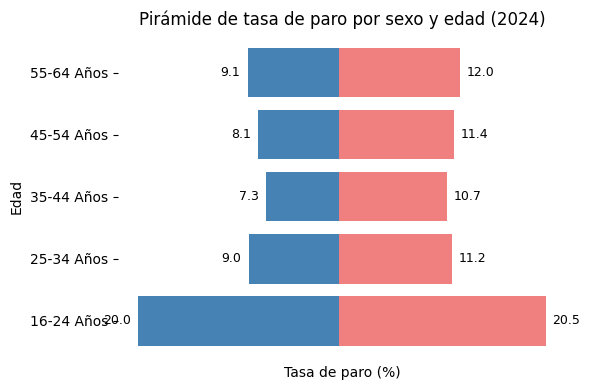

In [16]:

fig, ax = plt.subplots(figsize=(6, 4))

# Convertimos en valores negativos la tasa de paro de los hombres para la pirámide
hombres = -tasa_paro2024["Hombre"].values
mujeres = tasa_paro2024["Mujer"].values
edades = tasa_paro2024.index.tolist()

ax.barh(edades, hombres, color='steelblue', label="Hombres")
ax.barh(edades, mujeres, color='lightcoral', label="Mujeres")

# Etiquetas y estética
ax.set_xlabel("Tasa de paro (%)")
ax.set_ylabel("Edad")
ax.set_title("Pirámide de tasa de paro por sexo y edad (2024)")
ax.set_yticks(edades)
ax.set_yticklabels(edades)
ax.set_xlim(min(hombres) * 1.1, max(mujeres) * 1.1)

# Etiquetas numéricas de las barras
for i, (h, m) in enumerate(zip(hombres, mujeres)):
    ax.text(h - 0.7, i, f'{abs(h):.1f}', va='center', ha='right', color='black', fontsize=9)
    ax.text(m + 0.7, i, f'{m:.1f}', va='center', ha='left', color='black', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.set_ticks([])
ax.xaxis.set_ticklabels([])

ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



In [17]:
dif_hm = abs(tasa_paro2024["Mujer"] - tasa_paro2024["Hombre"]) 
dif_hm

Edad
16-24 Años    0.5
25-34 Años    2.2
35-44 Años    3.4
45-54 Años    3.3
55-64 Años    2.9
dtype: Float64

Cosas interesantes:

- Paro entre los jóvenes: Podemos ver que entre las edades de 16 a 24 años hay una alarmante tasa de paro y una gran diferencia con las otras franjas de edad. Cabe recalcar que esta tasa de paro se calcula exclusivamente con la gente que esta buscando trabajo activamente, es decir los estudiantes no forman parte del porcentaje de los parados. Uno de cada cinco jóvenes no encuentra trabajo.

- Paro entre mujeres: Nos fijamos que los hombres tienen 0.5 % más de paro que las mujeres en las edades jóvenes. En las siguientes franjas de edad vemos como las mujeres tienen bastante más paro, maximizandose entre los 35 a 44 años donde tenemos un 3.4% de diferencia.

- Paro general: Entre los 25 a 54 observamos que hay cierta estabilidad, donde se minimiza entre los 35 y 44. Hay un aumento considerable ente las edades de 55 a 64 años con un aumento del 1.6% respecto a la anterior franja.

### 4.2 Fluctuación de paro por año

Veremos como ha evolucionado el paro entre los años 2019 a 2024:

In [18]:
aoi_total = df.groupby(["AÑO","Estado"])["FACTOREL"].sum().unstack(["Estado"])
aoi_pct = aoi_total.div(aoi_total.sum(axis=1), axis=0) * 100
aoi_pct.round(1).T

AÑO,2019,2020,2021,2022,2023,2024
Estado,,,,,,
Ocupado,85.9,84.5,85.2,87.1,87.9,88.7
Parado,14.1,15.5,14.8,12.9,12.1,11.3


In [19]:
aoi_sexo = df.groupby(["AÑO","Estado","Sexo"])["FACTOREL"].sum().unstack(["Estado","Sexo"])
aoi_sexo = aoi_sexo.div(aoi_sexo.sum(axis=1), axis=0) * 100
aoi_sexo.round(1).T

AÑO             2019  2020  2021  2022  2023  2024
Estado  Sexo                                      
Ocupado Hombre  46.7  45.9  45.9  46.8  47.1  47.5
        Mujer   39.2  38.6  39.3  40.3  40.7  41.2
Parado  Hombre   6.6   7.4   6.9   5.9   5.6   5.4
        Mujer    7.5   8.1   7.9   7.0   6.5   6.0

In [20]:
aoi_sexo_pct = aoi_sexo.div(aoi_sexo.T.groupby(level="Sexo").sum().T) * 100
aoi_sexo_pct.round(1)

Estado Ocupado       Parado      
Sexo    Hombre Mujer Hombre Mujer
AÑO                              
2019      87.6  84.0   12.4  16.0
2020      86.1  82.6   13.9  17.4
2021      86.9  83.3   13.1  16.7
2022      88.7  85.2   11.3  14.8
2023      89.4  86.2   10.6  13.8
2024      89.8  87.3   10.2  12.7

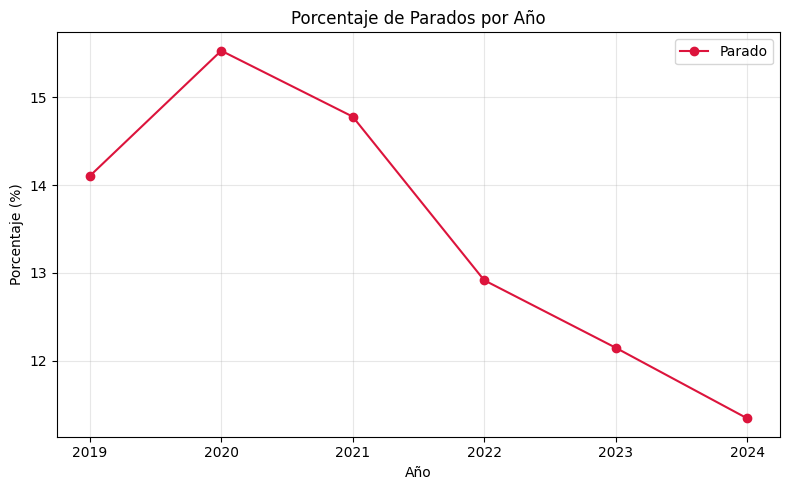

In [21]:
# Grafico de porcentaje de parados por año
plt.figure(figsize=(8, 5))
plt.plot(aoi_pct.index, aoi_pct["Parado"], marker='o', color='crimson', label='Parado')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.title('Porcentaje de Parados por Año')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

Vemos una clara tendencia descendente en el gráfico con un gran pico entre los años 2019 y 2020, pasando de 14.1% de paro en 2019 a la cifra de 15.5% en 2020. Esto es debido a las catastróficas consecuencias del COVID-19. Estar confinados requiere pagar a empleados inactivos si es un trabajo manual, lo que genera pérdidas y hace que los empresarios filtren los empleados a solo los imprescindibles. Esto genera mucha gente en la calle con necesidad de empleo. Después de la crisis, el paro baja incluso más de lo que había antes de la pandemia: en 2024 está en 11.3%. El paro no es el único indicador para diagnosticar la salud de un país pero bajo este parámetro vemos una clara mejoría.

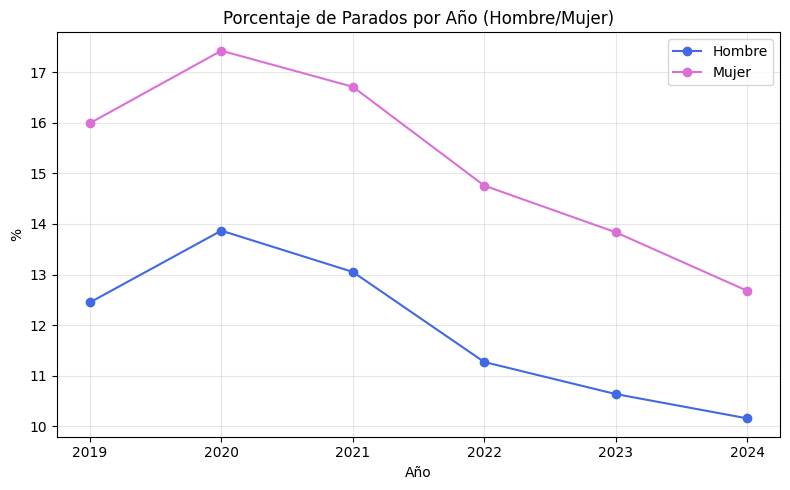

In [22]:
# Grafico de porcentaje de parados por año (hombre y mujer)
plt.figure(figsize=(8, 5))
plt.plot(aoi_sexo_pct.index, aoi_sexo_pct[("Parado", "Hombre")], marker='o', color='royalblue', label='Hombre')
plt.plot(aoi_sexo_pct.index, aoi_sexo_pct[("Parado", "Mujer")], marker='o', color='orchid', label='Mujer')
plt.ylabel('%')
plt.xlabel('Año')
plt.title('Porcentaje de Parados por Año (Hombre/Mujer)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

In [23]:
diferencia_paro_hm = abs(aoi_sexo_pct[("Parado", "Mujer")] - aoi_sexo_pct[("Parado", "Hombre")])
diferencia_paro_hm

AÑO
2019    3.546504
2020    3.560274
2021     3.66342
2022     3.49046
2023    3.201298
2024    2.524127
dtype: Float64

Vemos que las mujeres han sido más afectadas en la crisis del COVID-19 ya que es donde se maximiza la desigualdad con los hombres con un 3.66 de diferencia. Se minimiza en 2024 con un 2.52, lo que indica que se esta llegado a cierta igualdad en este parámetro.

### 4.3 Distribuciones de ocupados por sexo

Vemos ahora los como están distribuidos los ocupados españoles por sexo en 2024:

In [24]:
aoi_sexo = df.groupby(["AÑO","Estado","Sexo"])["FACTOREL"].sum().unstack(["Estado","Sexo"])
aoi_sexo = aoi_sexo.div(aoi_sexo.sum(axis=1), axis=0) * 100
aoi_sexo.round(1).T

AÑO             2019  2020  2021  2022  2023  2024
Estado  Sexo                                      
Ocupado Hombre  46.7  45.9  45.9  46.8  47.1  47.5
        Mujer   39.2  38.6  39.3  40.3  40.7  41.2
Parado  Hombre   6.6   7.4   6.9   5.9   5.6   5.4
        Mujer    7.5   8.1   7.9   7.0   6.5   6.0

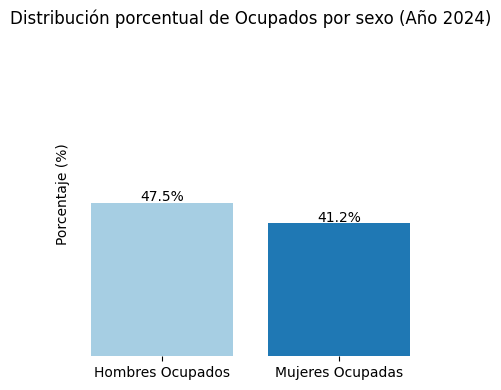

In [25]:
aoi_sexo_2024 = aoi_sexo.loc[2024]

# Extraemos los valores de ocupados por sexo
labels = ['Hombres Ocupados', 'Mujeres Ocupadas']
values = [
    aoi_sexo_2024[('Ocupado', 'Hombre')],
    aoi_sexo_2024[('Ocupado', 'Mujer')]
]

plt.figure(figsize=(4, 4))
plt.bar(labels, values, color=[plt.cm.Paired.colors[0], plt.cm.Paired.colors[1]])
plt.title('Distribución porcentual de Ocupados por sexo (Año 2024)')
plt.ylabel('Porcentaje (%)')
plt.gca().axes.get_yaxis().set_ticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
for i, v in enumerate(values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [26]:
# Serie: Diferencia porcentual de ocupados entre hombres y mujeres para cada año
diferencia_ocupados_h_m = aoi_sexo[('Ocupado', 'Hombre')] - aoi_sexo[('Ocupado', 'Mujer')]
diferencia_ocupados_h_m

AÑO
2019    7.434382
2020    7.288477
2021    6.593334
2022    6.575923
2023    6.373086
2024    6.341766
dtype: Float64

Vemos que hay un 6.34% más de hombres ocupados que mujeres. Aunque esta diferencia parece menguar con los años.

### 4.4 Distribuciones de ocupados por edad

Haremos lo mismo por franjas de edad:

In [27]:
aoi_edad = df.groupby(["AÑO", "Estado", "Edad"], observed=False)["FACTOREL"].sum().unstack(["Estado", "Edad"])
aoi_edad = aoi_edad.div(aoi_edad.sum(axis=1), axis=0) * 100
aoi_edad.round(1).T

AÑO                 2019  2020  2021  2022  2023  2024
Estado  Edad                                          
Ocupado 16-24 Años  11.9  10.9  11.4  12.3  12.7  13.0
        25-34 Años  20.8  19.5  19.1  19.0  19.2  19.2
        35-44 Años  26.4  26.2  26.2  26.2  25.8  25.3
        45-54 Años  20.8  21.3  21.4  21.9  22.3  22.8
        55-64 Años   6.0   6.7   7.1   7.6   7.9   8.3
Parado  16-24 Años   3.9   4.5   4.2   3.6   3.4   3.3
        25-34 Años   3.0   3.5   3.1   2.6   2.5   2.1
        35-44 Años   3.4   3.6   3.3   2.9   2.7   2.5
        45-54 Años   3.0   3.0   3.1   2.9   2.6   2.4
        55-64 Años   0.8   0.9   1.0   1.0   0.9   1.0

In [28]:
# Porcentaje de ocupados por edad respecto al total de ocupados cada año
aoi_edad_ocupados = df.groupby(["AÑO", "Estado", "Edad"], observed=False)["FACTOREL"].sum().unstack(["Estado", "Edad"])
porcentaje_ocupados_por_edad = aoi_edad_ocupados['Ocupado'].div(aoi_edad_ocupados['Ocupado'].sum(axis=1), axis=0) * 100

<Figure size 1000x600 with 0 Axes>

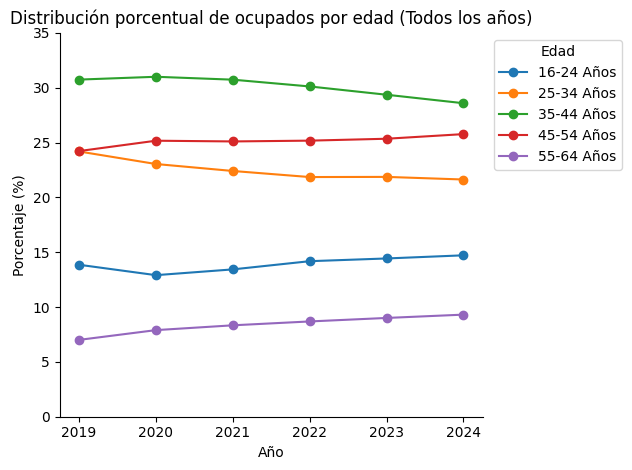

In [29]:
# Gráfico de líneas de la distribución porcentual de ocupados por edad (todos los años)
plt.figure(figsize=(10, 6))
porcentaje_ocupados_por_edad.plot(kind='line', marker='o')
plt.title('Distribución porcentual de ocupados por edad (Todos los años)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.ylim(0, 35)
plt.legend(title='Edad', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Aqui podemos observar como más de la mitad de trabajadores están entre los 35 a los 54 años. Los que menos participan en el ámbito laboral són los españoles entre las edades 16 a los 24 y entre los 55 a 64 años. Ya hemos visto antes la desorbitada tasa de paro entre los jóvenes, pero en el segundo caso vemos que la tasa de paro y la tasa de empleo no tiene la misma correlación.

Observamos que las franjas de edad que más han crecido són las de más altas, entre 45 y 64 años. En las edades dentro de 45 y 54 años ha habido un crecimiento de un 2.1% entre los años 2019 y 2024. De la misma manera para los encuestados de 55 a 64 años con un 2.3%.

Las edades intermedias han sufrido un decrecimiento en el mundo laboral, con una bajada del 2% y 1% para las edades de 25 a 34 y 35 y 44 años respectivamente.

Observamos también que en el año 2019 tenía casi la misma cantidad de personas entre 25-34 y 45-54 años. Al cabo del tiempo estas franjas se van separando hasta llegar a 2024 donde encontramos una diferencia de ~3.6%.

Los jovenes han aumentado un 1.1% desde 2019.

In [30]:
aoi_edad_pct = aoi_edad.div(aoi_edad.T.groupby(level="Edad", observed=False).sum().T) * 100
aoi_edad_pct = aoi_edad_pct.round(1)
aoi_edad_pct.T

AÑO                 2019  2020  2021  2022  2023  2024
Estado  Edad                                          
Ocupado 16-24 Años  75.3  70.8  73.0  77.6  78.6  79.8
        25-34 Años  87.4  84.7  86.1  87.9  88.7  89.9
        35-44 Años  88.5  87.8  88.7  90.1  90.7  91.0
        45-54 Años  87.4  87.6  87.2  88.3  89.4  90.4
        55-64 Años  88.4  88.6  88.0  88.6  89.3  89.6
Parado  16-24 Años  24.7  29.2  27.0  22.4  21.4  20.2
        25-34 Años  12.6  15.3  13.9  12.1  11.3  10.1
        35-44 Años  11.5  12.2  11.3   9.9   9.3   9.0
        45-54 Años  12.6  12.4  12.8  11.7  10.6   9.6
        55-64 Años  11.6  11.4  12.0  11.4  10.7  10.4

Aqui podemos ver la disminución del paro por años. La más notoria es la de los jóvenes, pasando de un 24.7% en 2019 a un 20.2% en 2024 (Aunque siga siendo una cifra astronómicamente alta).

### 4.5 Paro por nivel de estudios

In [31]:
# Porcentaje de paro por nivel de estudios (NFORMA) para cada año
aoi_estudios = df.groupby(["AÑO", "Estado", "NFORMA"])["FACTOREL"].sum().unstack(["Estado", "NFORMA"])

# Suma de ocupados+parados por nivel de estudios en cada año
totales_estudios = aoi_estudios.T.groupby(level="NFORMA").sum().T

# Calcula el porcentaje de parados respecto al total, por nivel de estudios y año
tasa_paro_estudios = aoi_estudios.xs("Parado", level="Estado", axis=1).div(totales_estudios) * 100

tasa_paro_estudios = tasa_paro_estudios.round(2)

nforma_map = {
    "AN": "Analfabetos",
    "P1": "Primaria incompleta",
    "P2": "Primaria completa",
    "S1": "Secundaria 1ª etapa (ESO)",
    "SG": "Secundaria 2ª etapa (Bachillerato)",
    "SP": "Secundaria 2ª etapa (FP Grado Medio)",
    "SU": "Superior"
}

# Aplicar el mapeo a todas las columnas del DataFrame de tasas
tasa_paro_estudios.columns = tasa_paro_estudios.columns.map(nforma_map)
tasa_paro_estudios = tasa_paro_estudios.T
tasa_paro_estudios

AÑO,2019,2020,2021,2022,2023,2024
NFORMA,,,,,,
Analfabetos,37.62,38.64,33.82,33.39,36.41,33.07
Primaria incompleta,28.96,29.41,28.91,24.64,21.8,26.56
Primaria completa,25.9,27.78,26.81,26.58,25.38,23.31
Secundaria 1ª etapa (ESO),18.86,20.24,20.07,17.83,16.39,15.49
Secundaria 2ª etapa (Bachillerato),14.16,16.98,16.05,14.23,13.18,12.43
Secundaria 2ª etapa (FP Grado Medio),14.95,15.87,16.08,13.84,13.32,12.06
Superior,8.61,10.23,9.21,7.62,7.36,6.9


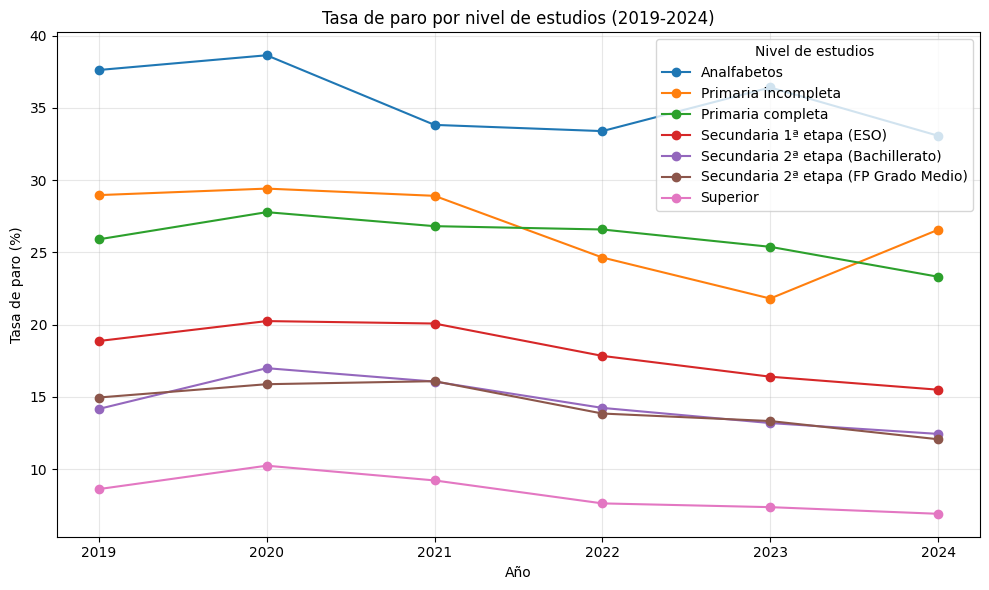

In [32]:
# Gráfico de líneas de la tasa de paro por nivel de estudios por año

plt.figure(figsize=(10,6))
for nivel in tasa_paro_estudios.index:
    plt.plot(tasa_paro_estudios.columns, tasa_paro_estudios.loc[nivel], marker='o', label=nivel)

plt.title("Tasa de paro por nivel de estudios (2019-2024)")
plt.xlabel("Año")
plt.ylabel("Tasa de paro (%)")
plt.legend(title="Nivel de estudios")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Según los datos, los analfabetos presentan la tasa de paro siempre más alta, con disminución hasta 30.55% en 2022 y un fuerte aumento en 2023 hasta un 39.75%. La segunda tasa más elevada se observa en el caso de la población con primaria incompleta, muy variable a lo largo del periodo, con su mínimo en el 2023 con un 22.5% creciendo rápidamente hasta el 28.44%. Los encuestados con la primaria tiene un comportamiento contrario a los que la tienen incompleta. Se maximiza en 2023 con un 30.16% en 2023 y se minimiza en 2024 con un 24.49%.

Los encuestados estudios superiores a la primaria tienen un comportamiento muy similar. La gente con mínimo bachillerato esta a la par con los que han cursado Grado Medio. Los que han cursado estudios superiores suelen mantener una media de ~7%.

Graficamos para 2024:

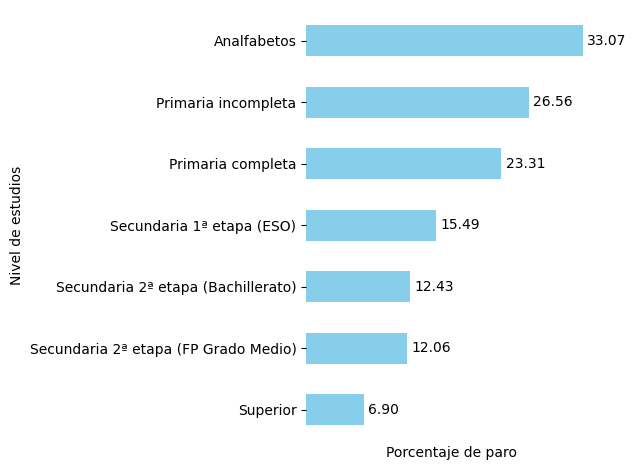

In [33]:

# Gráfico de barras horizontales de la tasa de paro por nivel de estudios en 2024 usando .loc
tasa_2024 = tasa_paro_estudios.loc[:, 2024]
ax = tasa_2024.sort_values().plot(kind='barh', color='skyblue', legend=False)

plt.xlabel("Porcentaje de paro")
plt.ylabel("Nivel de estudios")

ax.set_xticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

for i, (value, name) in enumerate(zip(tasa_2024.sort_values(), tasa_2024.sort_values().index)):
    ax.text(value + 0.5, i, f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.6 Duración del paro

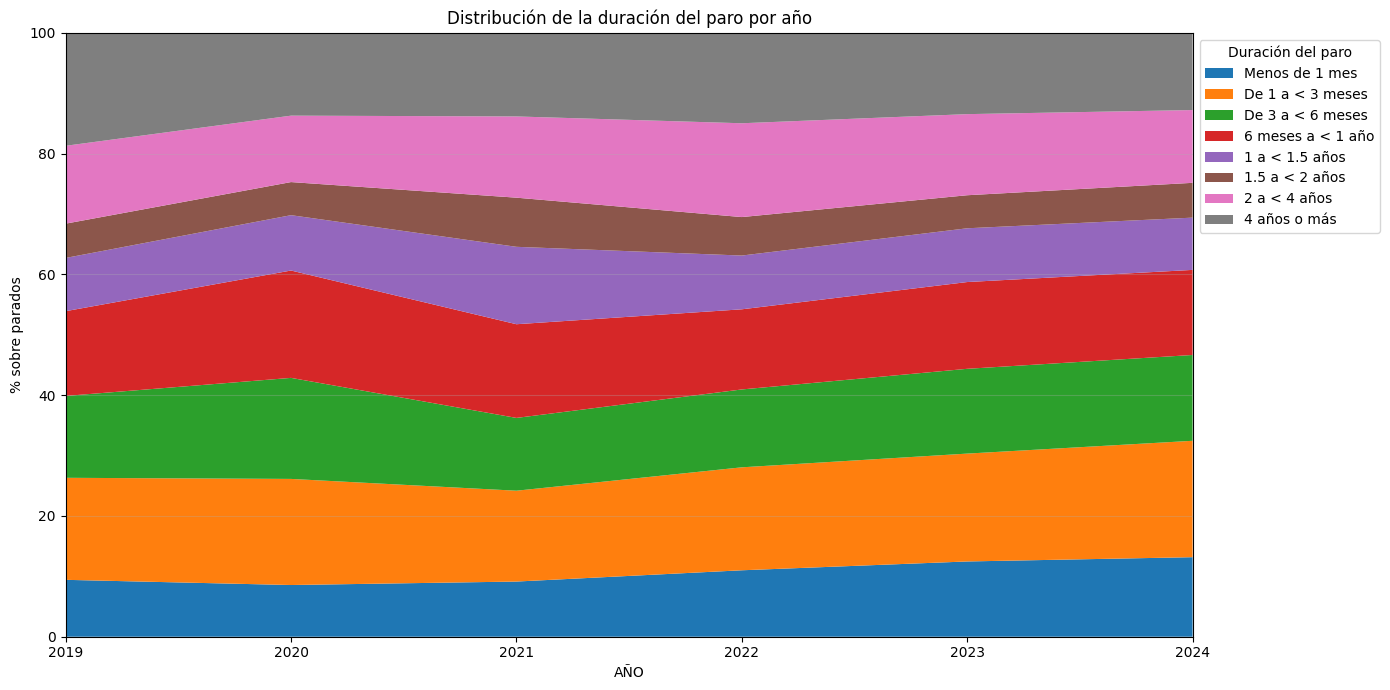

In [34]:
itbu_map = {
    1: "Menos de 1 mes",
    2: "De 1 a < 3 meses",
    3: "De 3 a < 6 meses",
    4: "6 meses a < 1 año",
    5: "1 a < 1.5 años",
    6: "1.5 a < 2 años",
    7: "2 a < 4 años",
    8: "4 años o más"
}

df_parados_validos = df[
    (df["Estado"] == "Parado") &
    (df["ITBU"].notna()) &
    (df["ITBU"].isin(itbu_map.keys()))
].copy()

df_parados_validos["ITBU"] = df_parados_validos["ITBU"].map(itbu_map)

itbu_yr_tab = (
    df_parados_validos
    .groupby(["AÑO", "ITBU"])["FACTOREL"]
    .sum()
    .unstack(fill_value=0)
)

itbu_yr_tab = itbu_yr_tab.reindex(columns=list(itbu_map.values()), fill_value=0)

itbu_yr_tab_pct = itbu_yr_tab.div(itbu_yr_tab.sum(axis=1), axis=0) * 100

itbu_yr_tab_pct.index = itbu_yr_tab_pct.index.astype(int)
datos_grafico = itbu_yr_tab_pct.T.values.astype(float)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(
    itbu_yr_tab_pct.index,
    datos_grafico,
    labels=list(itbu_map.values())
)

ax.set_title("Distribución de la duración del paro por año")
ax.set_xlabel("AÑO")
ax.set_ylabel("% sobre parados")
ax.set_xlim(itbu_yr_tab_pct.index.min(), itbu_yr_tab_pct.index.max())
ax.set_ylim(0, 100)
ax.legend(title="Duración del paro", bbox_to_anchor=(1, 1), loc="upper left")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

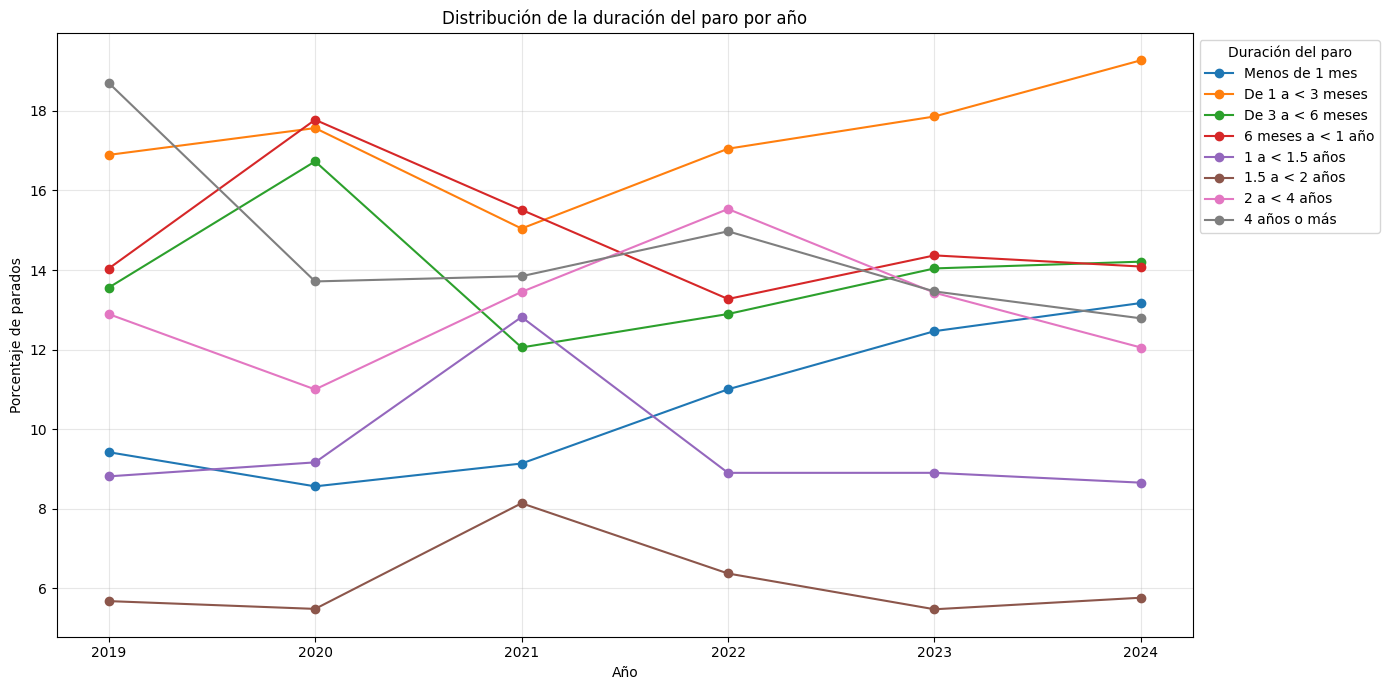

In [35]:
plt.figure(figsize=(14, 7))
for col in itbu_yr_tab_pct.columns:
    label = itbu_map.get(col, col)
    plt.plot(itbu_yr_tab_pct.index, itbu_yr_tab_pct[col], marker='o', label=label)
plt.title("Distribución de la duración del paro por año")
plt.ylabel("Porcentaje de parados")
plt.xlabel("Año")
plt.legend(title="Duración del paro", bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
itbu_yr_tab_pct

ITBU,Menos de 1 mes,De 1 a < 3 meses,De 3 a < 6 meses,6 meses a < 1 año,1 a < 1.5 años,1.5 a < 2 años,2 a < 4 años,4 años o más
AÑO,,,,,,,,
2019,9.421247,16.894434,13.557092,14.037041,8.813461,5.677887,12.893476,18.705361
2020,8.562212,17.568991,16.731329,17.777353,9.165457,5.481928,10.998914,13.713816
2021,9.136019,15.043156,12.054223,15.514441,12.818842,8.137883,13.450496,13.844939
2022,11.00193,17.050134,12.894569,13.271831,8.901856,6.371834,15.534383,14.973464
2023,12.463627,17.860152,14.040851,14.368208,8.90233,5.472421,13.430041,13.462369
2024,13.170944,19.272944,14.210899,14.08847,8.655242,5.762976,12.052419,12.786106


Lo primero que vemos en el gráfico son los dos picos en los intervalos de los que llevan parados entre 6 meses y un año y los que llevan entre 1 a 1.5 años, con un 15.51% y un 12.82% respectivamente. Esto es debido a la crisis del COVID-19, donde se llegó a la normalidad real por estos intervalos de tiempo.

Observamos un ascenso en los intervalos de tiempo más pequeños, en el caso de los parados durante menos de un mes este alcanza su mínimo en 2020 con un 8.56%, y para los encuestados parados entre 1 a 3 meses con un 15.04% en 2021.
El mayor descenso es el de los parados de más de 4 años, maximizándose en 2019 con un 18.70% y descendiendo hasta el 2024 llegando a la cifra de 12.78%.

### 4.7 Paro por Comunidades Autónomas

Ahora nos centraremos a dividir el paro por Comunidades Autónomas:

In [37]:
aoi_ccaa = df.groupby(["AÑO", "Estado", "CCAA"])["FACTOREL"].sum().unstack(["Estado", "CCAA"])

# Dividir dentro de cada CCAA (suma Ocupado+Parado por comunidad)
totales_ccaa = aoi_ccaa.T.groupby(level="CCAA").sum().T
tasa_paro_ccaa = aoi_ccaa.div(totales_ccaa) * 100


Los nombres de las comunidades autónomas están asignados por digitos. Cambiamos el nombre a los nombres de las CCAA.
Después creamos nuestro dataframe con el porcentaje de parados de cada comunidad.

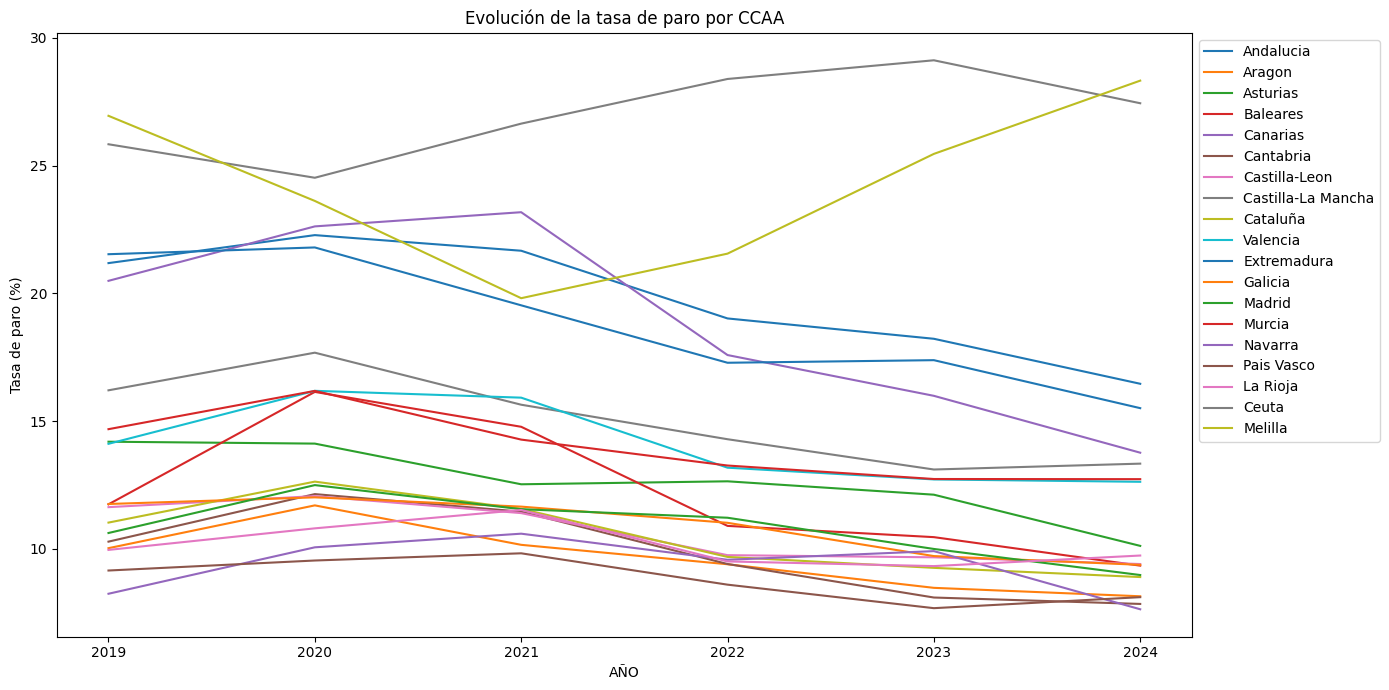

In [38]:
# Extraer la tasa de paro para cada año y CCAA
tasa_paro_ccaa_parado = tasa_paro_ccaa.xs("Parado", level="Estado", axis=1)

# Asegurarse de que los códigos de CCAA tengan dos dígitos como string
tasa_paro_ccaa_parado.columns = tasa_paro_ccaa_parado.columns.map(lambda x: f"{int(x):02}")

ccaa = {
    "01": "Andalucia",
    "02": "Aragon",
    "03": "Asturias",
    "04": "Baleares",
    "05": "Canarias",
    "06": "Cantabria",
    "07": "Castilla-Leon",
    "08": "Castilla-La Mancha",
    "09": "Cataluña",
    "10": "Valencia",
    "11": "Extremadura",
    "12": "Galicia",
    "13": "Madrid",
    "14": "Murcia",
    "15": "Navarra",
    "16": "Pais Vasco",
    "17": "La Rioja",
    "51": "Ceuta",
    "52": "Melilla"
}

# Renombrar columnas con el nombre de la comunidad
tasa_paro_ccaa_parado.columns = tasa_paro_ccaa_parado.columns.map(ccaa)
tasa_paro_ccaa_parado.index.name = "AÑO"

plt.figure(figsize=(14, 7))
tasa_paro_ccaa_parado.plot(ax=plt.gca())
plt.ylabel("Tasa de paro (%)")
plt.title("Evolución de la tasa de paro por CCAA")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()

In [39]:
# Crear nueva tabla "Impacto COVID" que es la resta de la tasa de paro 2020 menos 2019
impacto_covid = (tasa_paro_ccaa_parado.loc[2020] - tasa_paro_ccaa_parado.loc[2019]).to_frame(name="Impacto COVID")
impacto_covid.index.name = "CCAA"

impacto_ordenado = impacto_covid.sort_values(by="Impacto COVID", ascending=False)
print("Top 3 mayor impacto COVID:")
print(impacto_ordenado.head(3))
print("\nTop 3 menor impacto COVID:")
print(impacto_ordenado.tail(3))

Top 3 mayor impacto COVID:
          Impacto COVID
CCAA                   
Baleares       4.400784
Canarias       2.131535
Valencia       2.074359

Top 3 menor impacto COVID:
          Impacto COVID
CCAA                   
Asturias      -0.073989
Ceuta         -1.311499
Melilla       -3.332386


En el gráfico vemos como una buena cantidad de Comunidades Autónomas están por debajo del ~12.7%, todas con un comportamiento similar. Dentro de este intervalo Navarra ha sido la menos estable, con un mínimo en 2019 de 8.82% y ascendiendo hasta el 2023 maximizándose hasta el 10.59% finalmente descendiendo al 7.63%. De esta manera posicionandose como la Comunidad Autónoma con menos paro.

Asturias también ha tenido una bajada bastante positiva. Empezando con un 14.19% en 2019 bajando hasta un 10.12% en 2024. De las pocas Comunidades Autónomas que tenían más paro antes que durante la crisis del COVID-19.

Otra que ha sido bastante estable durante la crisis han sido las Islas Baleares, con un salto del 11.74% en 2019 a 16.14% en 2020, manteniéndose por el ~14-16% hasta el 2023 donde decrece hasta el 9.34% en 2024.

En el caso contrario tenemos a las Islas Canarias. Esta empieza subiendo de un 20.49% en 2019 hacia un 22.66% en 2020. A continuación tiene una increíble subida hasta el 25.84% en 2021, esto debido a una industria centrada en el turismo, poniendo a la región en un estado crítico durante el confinamiento. A pesar de su dependencia turística, ha mejorado notablemente hasta situarse en el 13.76% en 2024, aún por encima de la media nacional del 12.3%.

Extremadura y Andalucía tienen un comportamiento muy similar con la diferencia máxima en 2020, donde tienen 15.51% y 22.28% de tasa respectivamente. A continuación siguen un comportamiento parejo con una disparidad de aproximadamente el 3%.

Por último veamos los casos de Ceuta y Melilla. Con ambos un alto porcentaje de paro vemos cómo entre los años 2019 y 2023 tienen un comportamiento contrario. En 2019 Ceuta tiene un paro ~1% menos que Melilla (25.84% vs 26.95%). Entre 2021 y 2022 vemos que Ceuta aumenta hasta llegar a 28.39% de paro, con una diferencia de algo menos de 1% entre esos años con Melilla. Después de esto, en 2024 tanto Ceuta como Melilla bajan ligeramente hasta el 27.44% en el caso de Ceuta y 28.33% en el de Melilla.

Este enlace es un archivo GeoJSON que contiene los límites geográficos de las Comunidades Autónomas de España. Usaremos geopandas para asignar los porcentajes de paro a las comunidades autónomas.

In [40]:
# Leer el GeoJSON de comunidades autónomas
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"
spain = gpd.read_file(url)

spain = spain.set_index("name")

In [41]:
# Calcula la tasa de paro en 2024 por Comunidad Autónoma
tasa_paro_ccaa2024 = tasa_paro_ccaa_parado.loc[2024].to_frame(name="Tasa de Paro 2024")
tasa_paro_ccaa2024.index.name = "CCAA"
tasa_paro_ccaa2024 = tasa_paro_ccaa2024.sort_values(by="Tasa de Paro 2024")
tasa_paro_ccaa2024

,Tasa de Paro 2024
CCAA,
Navarra,7.633632
Cantabria,7.842733
Pais Vasco,8.107524
Aragon,8.142472
Cataluña,8.894839
Madrid,8.974299
Baleares,9.341845
Galicia,9.374067
Castilla-Leon,9.40521


In [42]:
spain = spain.join(tasa_paro_ccaa2024)

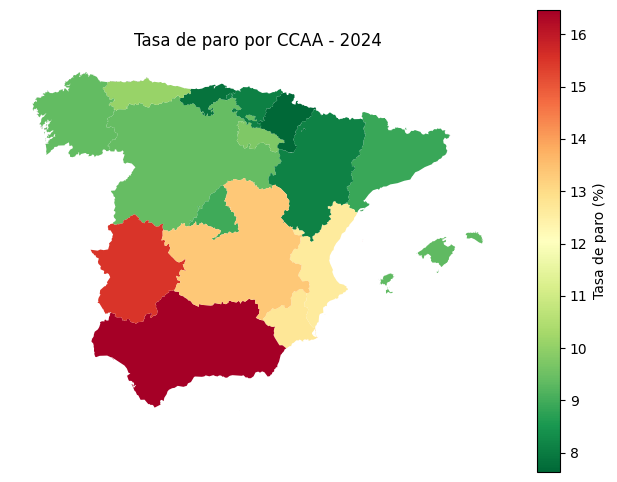

In [43]:
spain_ccm = spain.drop(["Ceuta", "Melilla","Canarias"])
fig, ax = plt.subplots(figsize=(8, 6))
spain_ccm.plot(column="Tasa de Paro 2024", 
           ax=ax, 
           legend=True, 
           cmap="RdYlGn_r", 
           legend_kwds={"label": "Tasa de paro (%)"})
ax.set_title("Tasa de paro por CCAA - 2024")
ax.axis("off")
plt.show()

Antes de analizar los datos, he eliminado tanto Ceuta y Melilla ya que prácticamente no se veian en el mapa, y sus porcentajes de paro eran tan altos que hacian ver como si el resto de comunidades autónomas no tuvieran paro. Además de eliminar las Islas Canarias ya que el mapa respecta su posición geográfica, lo que hace que la península se vea menos.

En el mapa podemos ver como el sud tiene una tasa de paro muchísimo mayor al resto de España con un casi 16.5% tanto Andalucía como Extremadura. Le sigue las Islas Canarias (13.76%) y un poco más arriba las Islas Baleares (9.34%). Baleares y Canarias tienen una economía muy dependiente del turismo estacional, lo que genera paro estructural en invierno y pleno empleo en verano. Las comunidades con menos paro son Navarra (7.63%), Cantabria (7.84%) y el País Vasco (8.11%).

### 4.7 Grupos más y menos vulnerables durante el COVID-19

Veamos ahora los grupos de encuestados (guiandonos por sexo, edad y Comunidad Autónoma) en los que ha habido un mayor y menor impacto por el COVID-19:

In [44]:
# Agrupamos por Sexo, Edad, CCAA en 2020 y calcular la tasa de paro
# Filtramos datos para 2019 y 2020
df_2019 = df[df["AÑO"] == 2019].copy()
df_2020 = df[df["AÑO"] == 2020].copy()

df_2019["Sexo"] = df_2019["SEXO1"].map(sexo_map)
df_2020["Sexo"] = df_2020["SEXO1"].map(sexo_map)

# Agrupamos y calculamos tasa de paro para 2019
tasa_paro_2019 = df_2019.groupby(
    ["Sexo", "Edad", "CCAA", "Estado"], observed=True
)["FACTOREL"].sum().unstack("Estado")
tasa_paro_2019["Tasa de Paro 2019"] = tasa_paro_2019["Parado"] / (tasa_paro_2019["Parado"] + tasa_paro_2019["Ocupado"]) * 100

# Agrupamos y calculamos tasa de paro para 2020
tasa_paro_2020 = df_2020.groupby(
    ["Sexo", "Edad", "CCAA", "Estado"], observed=True
)["FACTOREL"].sum().unstack("Estado")
tasa_paro_2020["Tasa de Paro 2020"] = tasa_paro_2020["Parado"] / (tasa_paro_2020["Parado"] + tasa_paro_2020["Ocupado"]) * 100

# Alineamos ambos dataframes y calculamos el impacto COVID
impacto = tasa_paro_2020[["Tasa de Paro 2020"]].join(
    tasa_paro_2019["Tasa de Paro 2019"],
    how="inner"
)
impacto["Impacto COVID"] = impacto["Tasa de Paro 2020"] - impacto["Tasa de Paro 2019"]

# Mostrar los 3 más altos y 3 más bajos
top3 = impacto["Impacto COVID"].sort_values(ascending=False).head(3)
bottom3 = impacto["Impacto COVID"].sort_values(ascending=True).head(3)

print("Top 3 incrementos de impacto COVID:")
print(impacto.loc[top3.index][["Tasa de Paro 2019", "Tasa de Paro 2020", "Impacto COVID"]])

print("\nTop 3 decrementos de impacto COVID:")
print(impacto.loc[bottom3.index][["Tasa de Paro 2019", "Tasa de Paro 2020", "Impacto COVID"]])

Top 3 incrementos de impacto COVID:
                        Tasa de Paro 2019  Tasa de Paro 2020  Impacto COVID
Sexo   Edad       CCAA                                                     
Mujer  16-24 Años 51            30.162004          44.730396      14.568392
Hombre 16-24 Años 15            13.665378          23.592969       9.927591
                  52             48.31895          58.026279       9.707329

Top 3 decrementos de impacto COVID:
                        Tasa de Paro 2019  Tasa de Paro 2020  Impacto COVID
Sexo   Edad       CCAA                                                     
Mujer  55-64 Años 52            24.570798          11.613153     -12.957645
Hombre 55-64 Años 17            18.332514           5.938579     -12.393936
Mujer  35-44 Años 51            40.849084          30.306208     -10.542876


## 5. Conclusiones

Ahora responderemos que tenemos toda la información procederemos a responder todas las preguntas planteadas:

1. Sigue siendo el sexo masculino el predominante en el sector laboral?

    Sí, los hombre siguen siendo notablemente predominante en el ámbito laboral, aun reduciéndose poco a poco (~1% a del 2019 al 2024).



2. Como afecta el paro a las mujeres comparado con los hombres?

    Hay una ligera predominancia de los hombres en el mercado laboral, aunque esta diferencia parece menguar a lo largo de los años. El único momento en el que el paro de los hombres es superior al de las mujeres es en las edades más jóvenes. Después los hombres toman la ventaja en el ámbito laboral.

3. Son de verdad los jóvenes los más afectados por el paro?

    La tasa de paro juvenil (16-24 años) alcanzó el 20.0% en 2024, más del doble que la media nacional (11.3%), con especial incidencia en mujeres (20.5% vs 20.0% en hombres, pero mayor en el tramo 25-44). Aunque mejora ligeramente con los años (24.1% en 2019, 28.5% en 2020, 26.8% en 2021, 21.7% en 2022, 21.2% en 2023, 20.0% en 2024), el paro juvenil sigue siendo demasiado alto. Existe una brecha estructural de inserción laboral en jóvenes, consistente con patrones históricos del mercado laboral español. Esto desemboca en fuga de talento, lo que puede generar consecuencias importantes a la economía española.
    

4. Como ha oscilado el paro general entre 2019 y 2024?
    
    Como era de esperarse, ha habido una gran subida del paro en épocas de COVID-19, teniendo una subida del 1.4% entre los años 2019 y 2020. Seguidamente tiene una importante disminución destacando el salto entre 2021 y 2022 donde hay una bajada del 1.9%, hasta llegar al 11.3% en 2024. En cómputo global, desde el 2019 al 2024 el paro ha pasado del 14.1% al 11.3%, una diferencia casi del 3%.

5. Como ha ido cambiando la duración de paro durante los años?

    Vemos una gran disminución de la duración del paro, aumentando la cantidad de encuestados parados durante menos de 1 mes (~6.3%) y entre 1 y 3 meses (~6.3%). Mientras tanto, disminuyen los parados durante más de 4 años (~2.5%).

6. Como ha oscilado el paro general entre 2019 y 2024?

7. Cual es la correlación entre paro y los diferentes niveles de formación? Hay una gran diferencia entre los estudios medios (FP) con estudios superiores?

    Hay una correlación directa entre el nivel de los estudios. Los encuestados con la ESO completada y superiores siguen una relación estrecha, fluctúan proporcionalmente a lo largo de los años. En contraparte, los encuestados con estudios por debajo de la ESO tienen tasas de paro más irregulares y mucho más altas (entre 25-38%).

8. Que comunidades autónomas son las que más paro tienen? Y las que menos?

    Ceuta y Melilla tienen más del doble de la media nacional (11.3%): (Ceuta 27.45%, Melilla 28.33%). Estas comunidades han tenido una alta subida de paro desde el 2019, empezando 22.31% y 25.92% respectivamente. Las comunidades del sur son las que más paro tienen dentro de la península (Extremadura 15.51%, Andalucía 16.46%) mientras que las del norte gozan de buenos números en comparación a la media de España (Cantabria 7.84%, Aragón 8.14%, País Vasco 8.11%). Cantabria ha sido la Comunidad Autónoma con mejor desempeño desde 2019, iniciando con un 12.20%.
    

9. Cuales han sido los grupos más y menos afectados por el COVID-19? 

    El grupo más afectado han sido las mujeres de entre 16 y 24 años de Ceuta. Pasando de un 30.16% de paro en 2019 y llegado a un 44.73% en 2020 (un incremento del +14.57%). Seguidamente tenemos a los hombres de 16 a 24 años de Melilla y Navarra con unos incrementos del +9.93% y 9.71% respectivamente.

    El menos afectado han sido las mujeres de Melilla de entre 55-64 años con un decrecimiento del -12.96%, seguido de los hombres entre 55 a 64 años de La Rioja con un -12.39%. Las mujeres de Ceuta entre los 25-34 años bajaron un -10.54%. Curioso ver como mujeres de una misma Comunidad Autónoma con solo una franja de edad de diferencia tienen resultados tan distintos.

10. Que comunidades Autónomas han gestionado mejor y peor la crisis?

    La Comunidad Autónoma más afectada han sido las Islas Baleares con un 4.40% de incremento de paro respecto a 2019. Seguidamente de otras afectadas como Canarias (2.13%), Valencia (2.07%), Madrid (1.87%), Cantabria (1.86%)
    Navarra	(1.82%). En contraparte Melilla tuvo un descenso de un -3.33%, no siendo afectada por la pandemia. Otras prácticamente inalteradas fueron: Extremadura (0.26%), Galicia (0.26%), Asturias (-0.07%), Ceuta (-1.31%).

## 6. Qué sigue

Podríamos hacer la comparación internacional de los indices de paro con otros países. Ver como diferentes países han gestionado la situación del COVID-19 en comparación al nuestro, ver las diferencias entre los hombres y las mujeres y en qué países los jovenes son más recompensados en el ámbito laboral.

Además sería bastante enriquecedor ver como se ha desarrollado estos datos a lo largo de los años, buscando información de mucho más en el pasado. Esta encuesta se hace desde el 2005, es posible que los datos del pasado sean radicalmente diferentes a los actuales.